### Overview


This notebook demonstrates the use of source separation within the score-based predictor-corrector framework of Song et al.  
By training a score-based model as a prior, a mixture of input images can be separated into individual components.  The algorithm used is based off of the BASIS separation framework from https://github.com/jthickstun/basis-separation



# Preparation

1. `git clone https://github.com/yang-song/score_sde_pytorch.git`

2. Install [required packages](https://github.com/yang-song/score_sde_pytorch/blob/main/requirements.txt)

3. `cd` into folder `score_sde_pytorch`, launch a local jupyter server and connect to colab following [these instructions](https://research.google.com/colaboratory/local-runtimes.html)

4. Download pre-trained [checkpoints](https://drive.google.com/drive/folders/1tFmF_uh57O6lx9ggtZT_5LdonVK2cV-e?usp=sharing) and save them in the `exp` folder.  This notebook only uses the `/ve/cifar10_ncsnpp_continuous/checkpoint_24.pth` checkpoint, but others could be used

In [1]:
!CUDA_LAUNCH_BLOCKING=1

In [2]:
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import io
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import importlib
import os
import functools
import itertools
import torch
from losses import get_optimizer
from models.ema import ExponentialMovingAverage

import torch.nn as nn
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
#import tensorflow_gan as tfgan
import tqdm
import io
import likelihood
import controllable_generation
from utils import restore_checkpoint
sns.set(font_scale=2)
sns.set(style="whitegrid")

import models
from models import utils as mutils
from models import ncsnv2
from models import ncsnpp
from models import ddpm as ddpm_model
from models import layerspp
from models import layers
from models import normalization
import sampling
from likelihood import get_likelihood_fn
from sde_lib import VESDE, VPSDE, subVPSDE
from sampling import (ReverseDiffusionPredictor, 
                      LangevinCorrector, 
                      EulerMaruyamaPredictor, 
                      AncestralSamplingPredictor, 
                      NoneCorrector, 
                      NonePredictor,
                      AnnealedLangevinDynamics)
                      #AnnealedLangevinDynamicsOld)

import datasets

/home/g4merz/.conda/envs/moconv/lib/python3.9/site-packages/torch/utils/cpp_extension.py:295: UserWarning: 

                               !! WARNING !!

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Your compiler (c++) is not compatible with the compiler Pytorch was
built with for this platform, which is g++ on linux. Please
use g++ to to compile your extension. Alternatively, you may
compile PyTorch from source using c++, and then you can also use
c++ to compile your extension.

See https://github.com/pytorch/pytorch/blob/master/CONTRIBUTING.md for help
with compiling PyTorch from source.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

                              !! WARNING !!

  warnings.warn(WRONG_COMPILER_WARNING.format(
/home/g4merz/.conda/envs/moconv/lib/python3.9/site-packages/torch/utils/cpp_extension.py:295: UserWarning: 

                               !! WARNING !!

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
    # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

1 Physical GPUs, 1 Logical GPUs


2025-08-26 21:48:46.709730: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13262 MB memory:  -> device: 0, name: Tesla V100-SXM2-16GB, pci bus id: 0004:05:00.0, compute capability: 7.0


In [4]:
#from models import ncsnv2
#importlib.reload(models)
#importlib.reload(ncsnv2)
#from models import ncsnv2


In [5]:
#Load the score-based model
from configs.ve import cifar10_ncsnpp_continuous as configs
ckpt_filename = "exp/ve/cifar10_ncsnpp_continuous/checkpoint_24.pth"
config = configs.get_config()  
sde = VESDE(sigma_min=config.model.sigma_min, sigma_max=config.model.sigma_max, N=config.model.num_scales)
sampling_eps = 1e-5

batch_size =   36
config.training.batch_size = batch_size
config.eval.batch_size = batch_size

random_seed = 0 

sigmas = mutils.get_sigmas(config)
scaler = datasets.get_data_scaler(config)
inverse_scaler = datasets.get_data_inverse_scaler(config)

score_model = mutils.create_model(config)

optimizer = get_optimizer(config, score_model.parameters())
ema = ExponentialMovingAverage(score_model.parameters(),
                               decay=config.model.ema_rate)
state = dict(step=0, optimizer=optimizer,
             model=score_model, ema=ema)


In [6]:
#@title Visualization code

def image_grid(x):
    size = config.data.image_size
    channels = config.data.num_channels
    img = x.reshape(-1, size, size, channels)
    w = int(np.sqrt(img.shape[0]))
    img = img.reshape((w, w, size, size, channels)).transpose((0, 2, 1, 3, 4)).reshape((w * size, w * size, channels))
    return img

def show_samples(x):
    x = x.permute(0, 2, 3, 1).detach().cpu().numpy()
    img = image_grid(x)
    plt.figure(figsize=(8,8))
    plt.axis('off')
    plt.imshow(img)
    plt.show()

def show_samples_subplot(x,ax):
    x = x.permute(0, 2, 3, 1).detach().cpu().numpy()
    img = image_grid(x)
    ax.axis('off')
    ax.imshow(img)
    #plt.show()
    
from skimage.metrics import structural_similarity as ssim
from scipy.optimize import linear_sum_assignment

def compute_ssim_matrix(pred_batch, target_batch):
    Np, Nt = pred_batch.shape[0], target_batch.shape[0]
    ssim_matrix = np.zeros((Np, Nt))
    for i in range(Np):
        for j in range(Nt):
            ssim_score = ssim(
                pred_batch[i], target_batch[j],
                channel_axis=0,
                data_range=pred_batch[i].max() - pred_batch[i].min()
            )
            ssim_matrix[i, j] = ssim_score
    return ssim_matrix

def global_match(x1, x2, img1, img2):
    
    x1 = x1.cpu().numpy()
    x2 = x2.cpu().numpy()
    img1 = img1.cpu().numpy()
    img2 = img2.cpu().numpy()

    # Combine predictions and originals
    pred_all = np.concatenate([x1, x2], axis=0)
    orig_all = np.concatenate([img1, img2], axis=0)

    # Compute SSIM and cost matrix
    ssim_matrix = compute_ssim_matrix(pred_all, orig_all)
    cost_matrix = 1 - ssim_matrix

    # Solve assignment problem
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # Reorder predictions to match originals
    matched_preds = pred_all[row_ind]
    matched_order = col_ind

    # Split matched predictions into two groups corresponding to img1 and img2
    matched_x1 = np.zeros_like(x1)
    matched_x2 = np.zeros_like(x2)

    for pred_idx, orig_idx in zip(row_ind, col_ind):
        if orig_idx < len(img1):
            # Image belongs to img1 group
            matched_x1[orig_idx] = pred_all[pred_idx]
        else:
            # Image belongs to img2 group
            matched_x2[orig_idx - len(img1)] = pred_all[pred_idx]

    return torch.tensor(matched_x1), torch.tensor(matched_x2)

    

# Predictor Corrector sampling


Recommended settings:

 | dataset | SDE | predictor | corrector | snr | n_steps |
|:----:|:----:|:----------:|:--------:|:---:|:----:|
|CIFAR-10 | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.16| 1|
|CIFAR-10 | VP | EulerMaruyamaPredictor | None | - | - |
|CIFAR-10 | subVP| EulerMaruyamaPredictor | None | - | - |
| LSUN/CelebA-HQ/FFHQ 256px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.075 | 1 |
| FFHQ 1024px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.15| 1 |

Check `probability_flow` to run PC sampling based on discretizing the probability flow ODE.

# Controllable generation

Several demonstrations on how to solve inverse problems with our SDE framework.

Recommended settings

| dataset | SDE | predictor | corrector | snr | n_steps |
|:----:|:----:|:----------:|:--------:|:---:|:----:|
|CIFAR-10 | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.16| 1|
|CIFAR-10 | VP | EulerMaruyamaPredictor | None | - | - |
|CIFAR-10 | subVP| EulerMaruyamaPredictor | None | - | - |
| LSUN/CelebA-HQ/FFHQ 256px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.075 | 1 |
| FFHQ 1024px | VE | ReverseDiffusionPredictor | LangevinCorrector | 0.15| 1 |

## Source separation

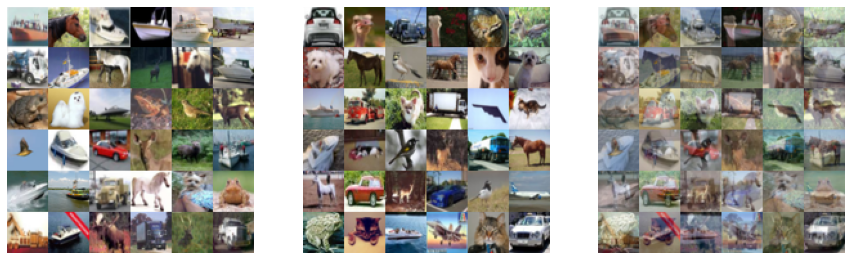

In [8]:

#@title PC source separator
train_ds, eval_ds, _ = datasets.get_dataset(config)
eval_iter = iter(eval_ds)
bpds = []

predictor = ReverseDiffusionPredictor #@param ["EulerMaruyamaPredictor", "AncestralSamplingPredictor", "ReverseDiffusionPredictor", "None"] {"type": "raw"}
corrector = AnnealedLangevinDynamics #@param ["LangevinCorrector", "AnnealedLangevinDynamics", "None"] {"type": "raw"}
snr = 0.2
n_steps = 1
probability_flow = False #@param {"type": "boolean"}

batch1 = next(eval_iter)
img1 = batch1['image']._numpy()
img1 = torch.from_numpy(img1).permute(0, 3, 1, 2).to(config.device)

batch2 = next(eval_iter)
img2 = batch2['image']._numpy()
img2 = torch.from_numpy(img2).permute(0, 3, 1, 2).to(config.device)


mixed = torch.Tensor(sum([img1.cpu(),img2.cpu()])).cuda().view(batch_size, 3, 32, 32)

fig,ax = plt.subplots(1,3,figsize=(15,5))
show_samples_subplot(img1,ax[0])
show_samples_subplot(img2,ax[1])
show_samples_subplot(mixed/2,ax[2])

In [ ]:
%%time
mixed_scale_img = scaler(mixed)
pc_separator = controllable_generation.get_mixture_conditional_sampler(
    sde, predictor, corrector, inverse_scaler,
    snr=snr, n_steps=1, probability_flow=probability_flow,
    continuous=config.training.continuous, denoise=True,M=200
)
x1,x2 = pc_separator(score_model, mixed_scale_img)

#show_samples(x)

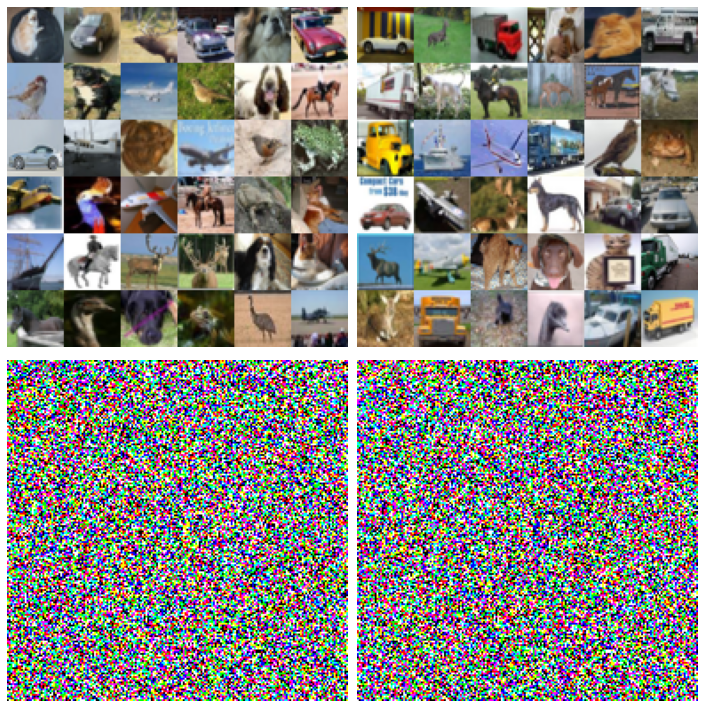

In [10]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(x1,ax[1][0])
show_samples_subplot(x2,ax[1][1])
plt.tight_layout()

In [49]:
mx1, mx2 = global_match(x1,x2,img1,img2)

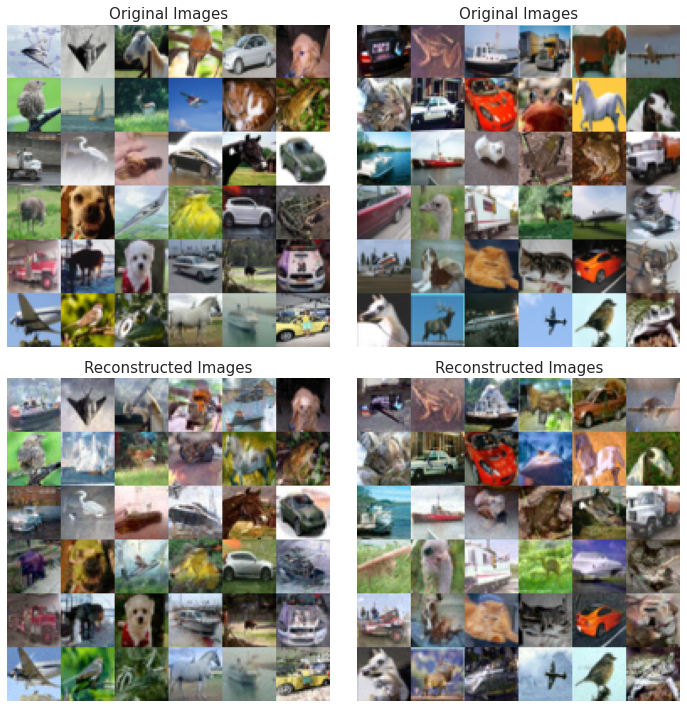

In [56]:
fig,ax = plt.subplots(2,2,figsize=(10,10))
show_samples_subplot(img1,ax[0][0])
show_samples_subplot(img2,ax[0][1])
show_samples_subplot(mx1,ax[1][0])
show_samples_subplot(mx2,ax[1][1])

ax[0][0].set_title('Original Images',fontsize=15)
ax[0][1].set_title('Original Images',fontsize=15)

ax[1][0].set_title('Reconstructed Images',fontsize=15)
ax[1][1].set_title('Reconstructed Images',fontsize=15)

plt.tight_layout()

In [58]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Example images (replace with your image arrays)
import numpy as np


def show_ex(img1,img2,x1,x2,ind):
    
    x1 = x1.cpu().numpy()
    x2 = x2.cpu().numpy()
    img1 = img1.cpu().numpy()
    img2 = img2.cpu().numpy()
    
    mixture = (img1+img2)/2

    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax1.imshow(img1[ind])
    ax2.imshow(img2[ind])
    
    ax_center = fig.add_subplot(gs[:, 1])  # spans both rows
    ax_center.imshow(mixture[ind])
    
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 2])
    ax3.imshow(x1[ind])
    ax4.imshow(x2[ind])

    # Plot images
    for ax in [ax1, ax2, ax3, ax4, ax_center]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

<Figure size 432x288 with 0 Axes>

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

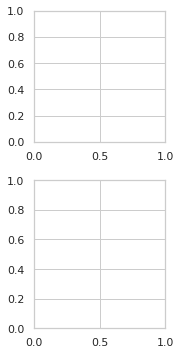

In [59]:
show_ex(img1,img2,mx1,mx2,20)